In [1]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

display(HTML("<style>.container { width:100% !important; }</style>"))
plt.rcParams['figure.figsize'] = (24, 10)
sns.set_theme(style="darkgrid")

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'


In [2]:
# 2. Data Loading (Subset for Visualization)
def load_data(limit=20):
    all_data = []
    files = glob.glob(os.path.join(DATA_DIR, '*.csv'))[:limit]
    
    for file_path in files:
        symbol = os.path.basename(file_path).replace('.csv', '')
        try:
            df = pd.read_csv(file_path)
            df['Date'] = pd.to_datetime(df['Date'])
            df = df.sort_values('Date').reset_index(drop=True)
            df['Symbol'] = symbol
            all_data.append(df)
        except Exception as e:
            pass
            
    return pd.concat(all_data, ignore_index=True)

data = load_data(limit=30) # Grab 30 just to be sure we have some trades


In [3]:
# 3. Regimes & Forward Returns Calculation
LOOKBACK = 34
HOLD_DAYS = 13

def enrich_data(df):
    df = df.copy()
    
    # Forward Return for Exit determination
    df['Exit_Index'] = df.index + HOLD_DAYS
    df['Fwd_Ret'] = df['Close'].shift(-HOLD_DAYS) / df['Close'] - 1
    
    # ER
    change = abs(df['Close'] - df['Close'].shift(LOOKBACK))
    volatility = df['Close'].diff().abs().rolling(LOOKBACK).sum()
    df['ER'] = change / volatility
    
    # WMA
    weights = np.arange(1, LOOKBACK + 1)
    df['WMA'] = df['Close'].rolling(LOOKBACK).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)
    df['WMA_Dist'] = (df['Close'] - df['WMA']) / df['WMA']
        
    return df

_data_list = []
for sym, grp in data.groupby('Symbol'):
    _data_list.append(enrich_data(grp))
data = pd.concat(_data_list, ignore_index=True)


In [4]:
# 4. Filter Trades (The Champion Strategy)
TEST_START = '2023-01-01'

# Only look at unseen data
test_data = data[data['Date'] >= TEST_START]

# Our Champion Parameters
ENTRY_ER = 0.6
WMA_AVOID = 0.03

# Find all trade triggers
trades = test_data[(test_data['ER'] > ENTRY_ER) & (test_data['WMA_Dist'] < WMA_AVOID) & (test_data['Fwd_Ret'].notna())]
print(f"Found {len(trades)} trades across the sample set.")


Found 105 trades across the sample set.


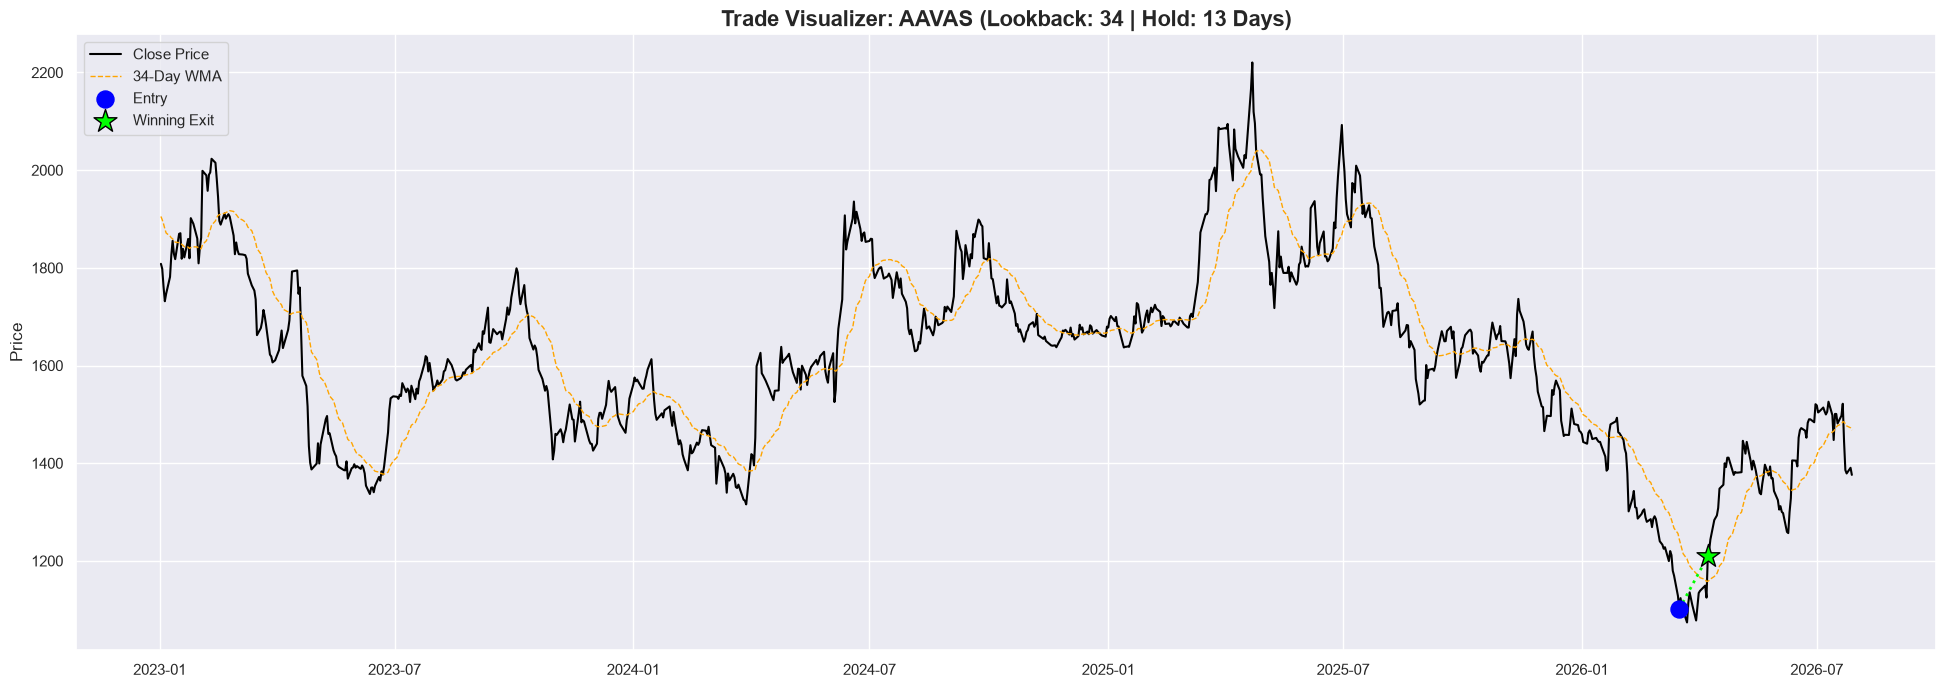

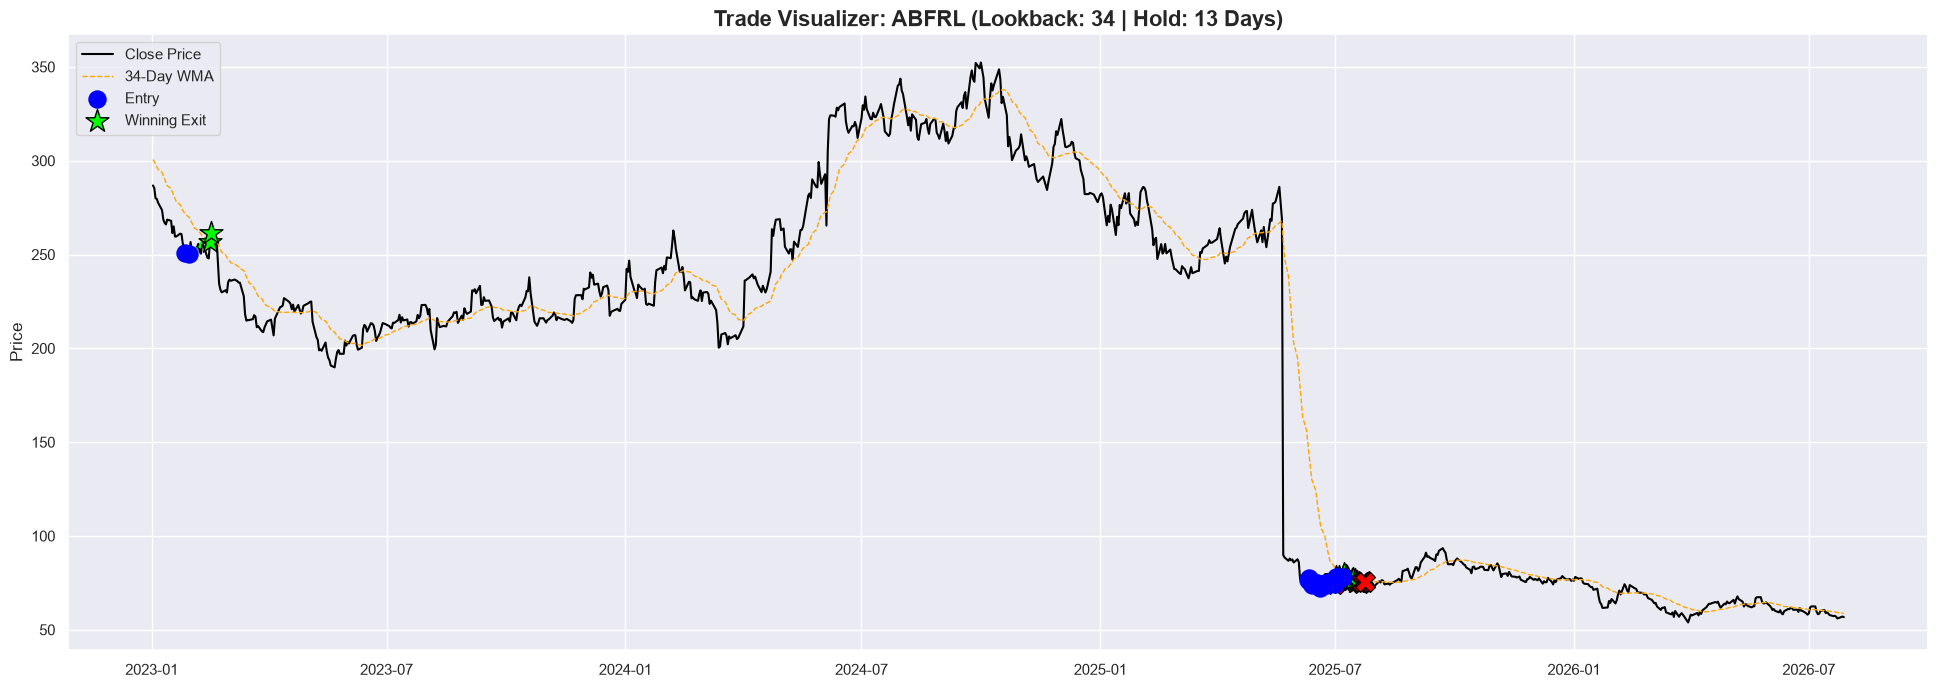

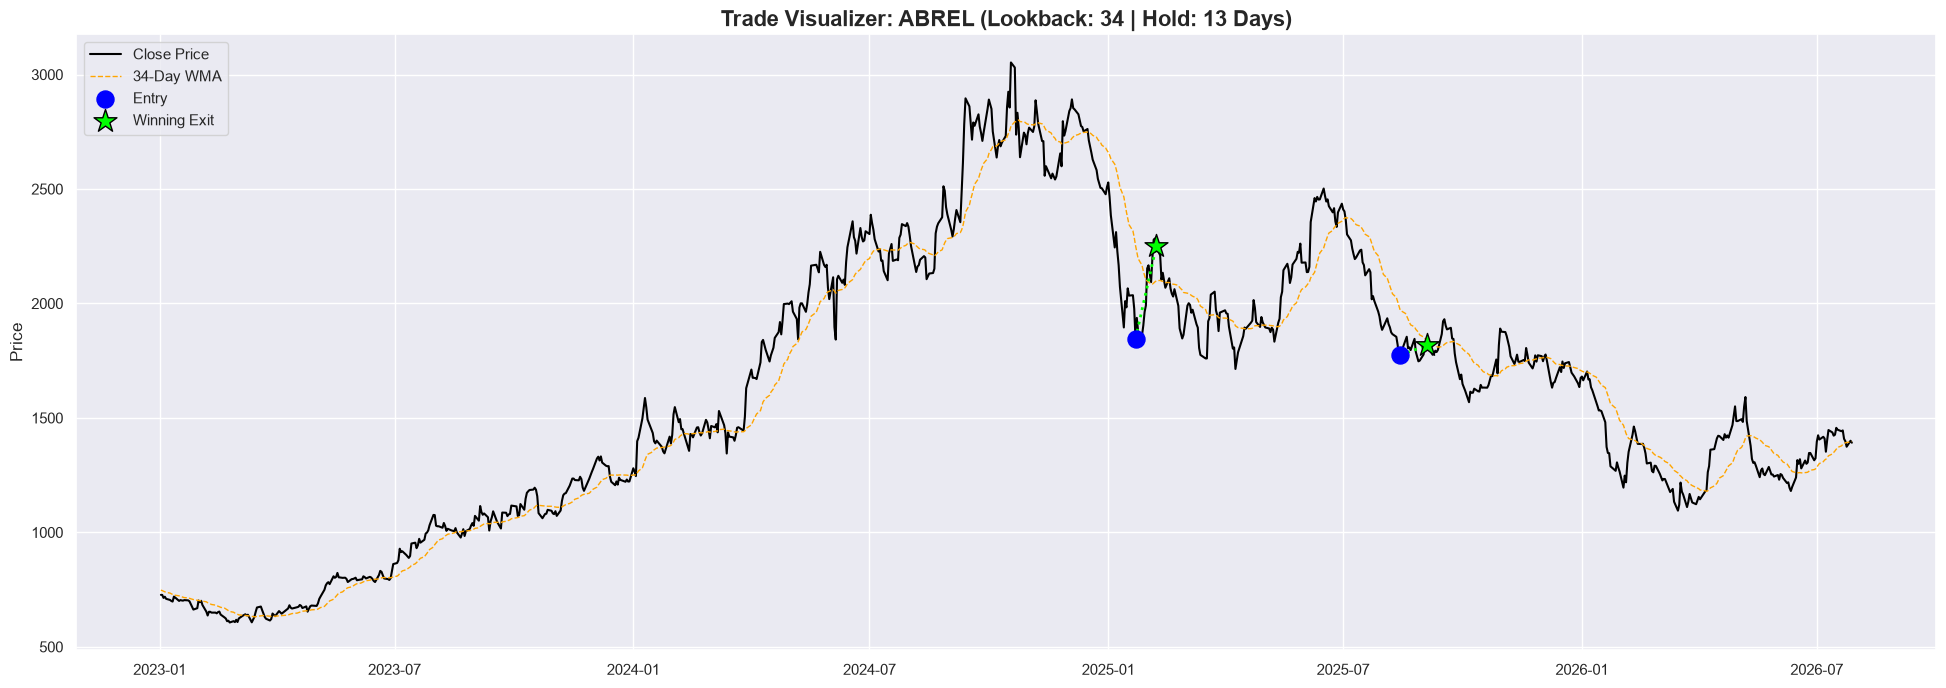

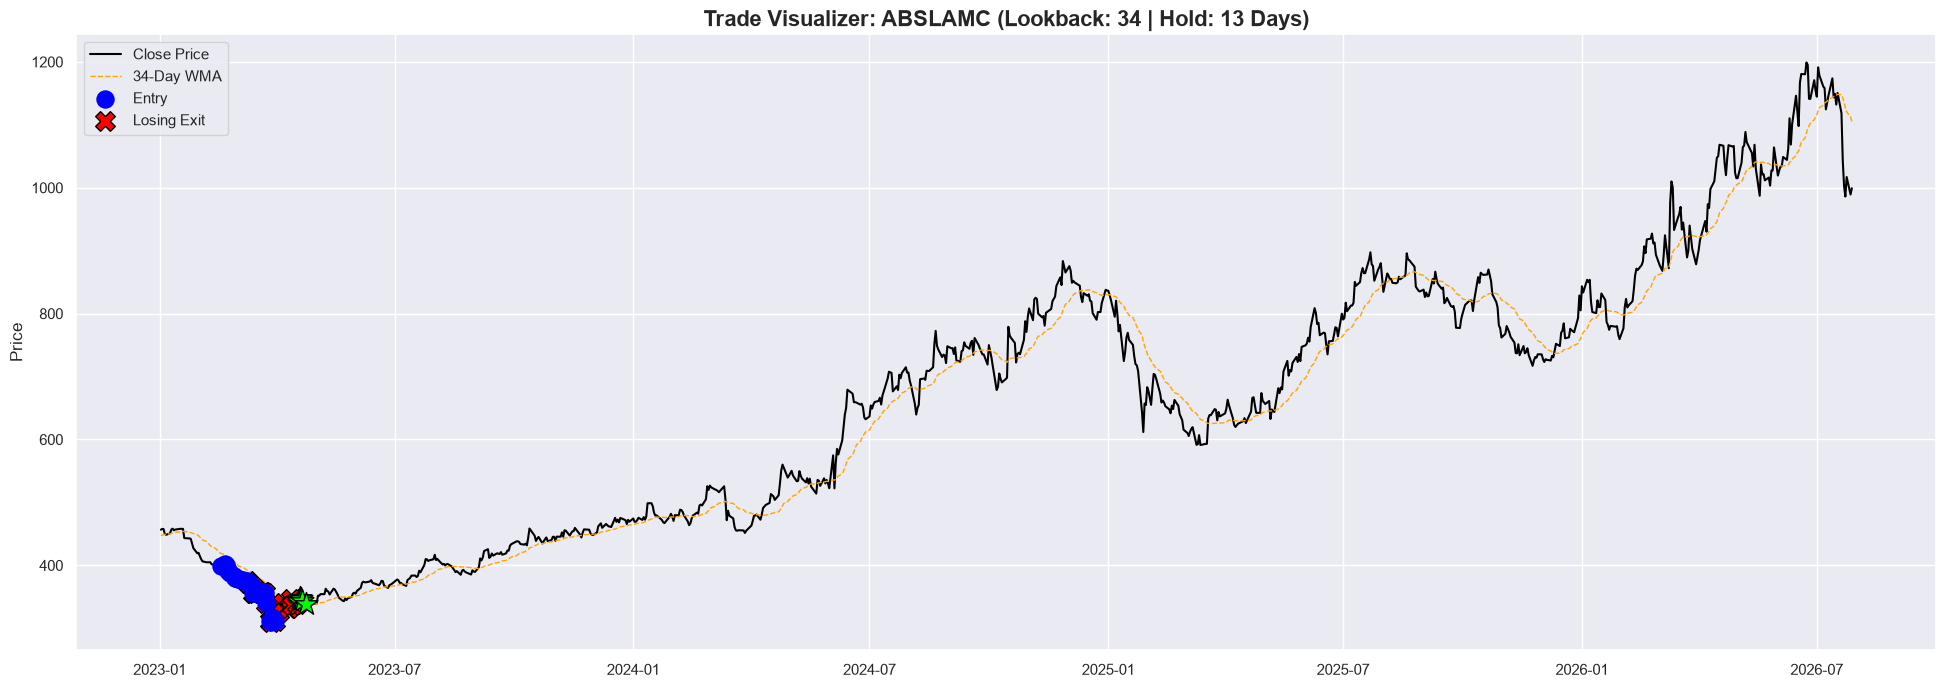

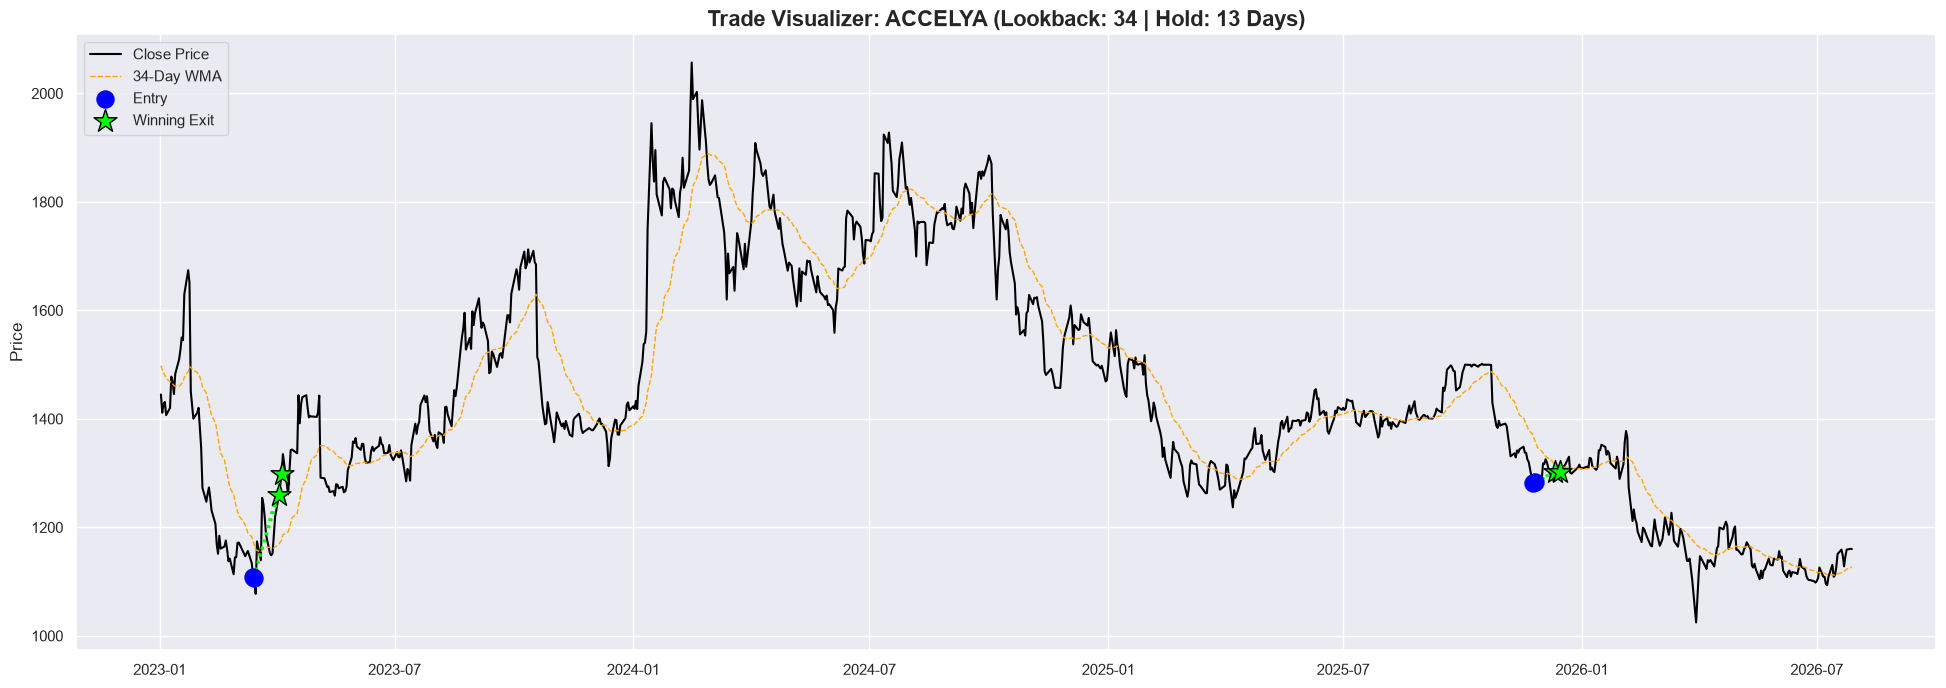

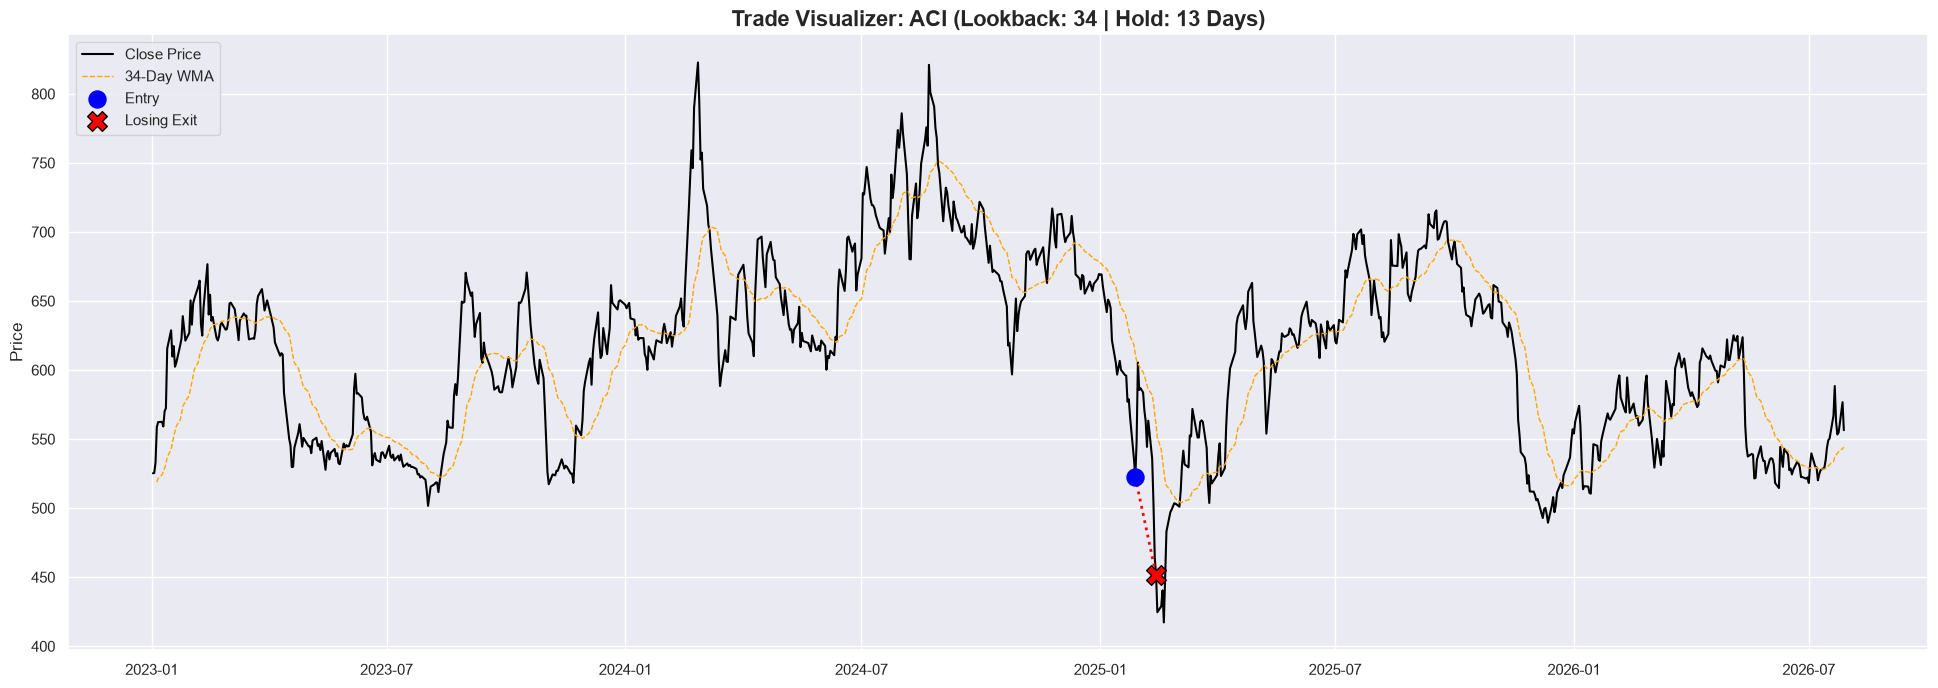

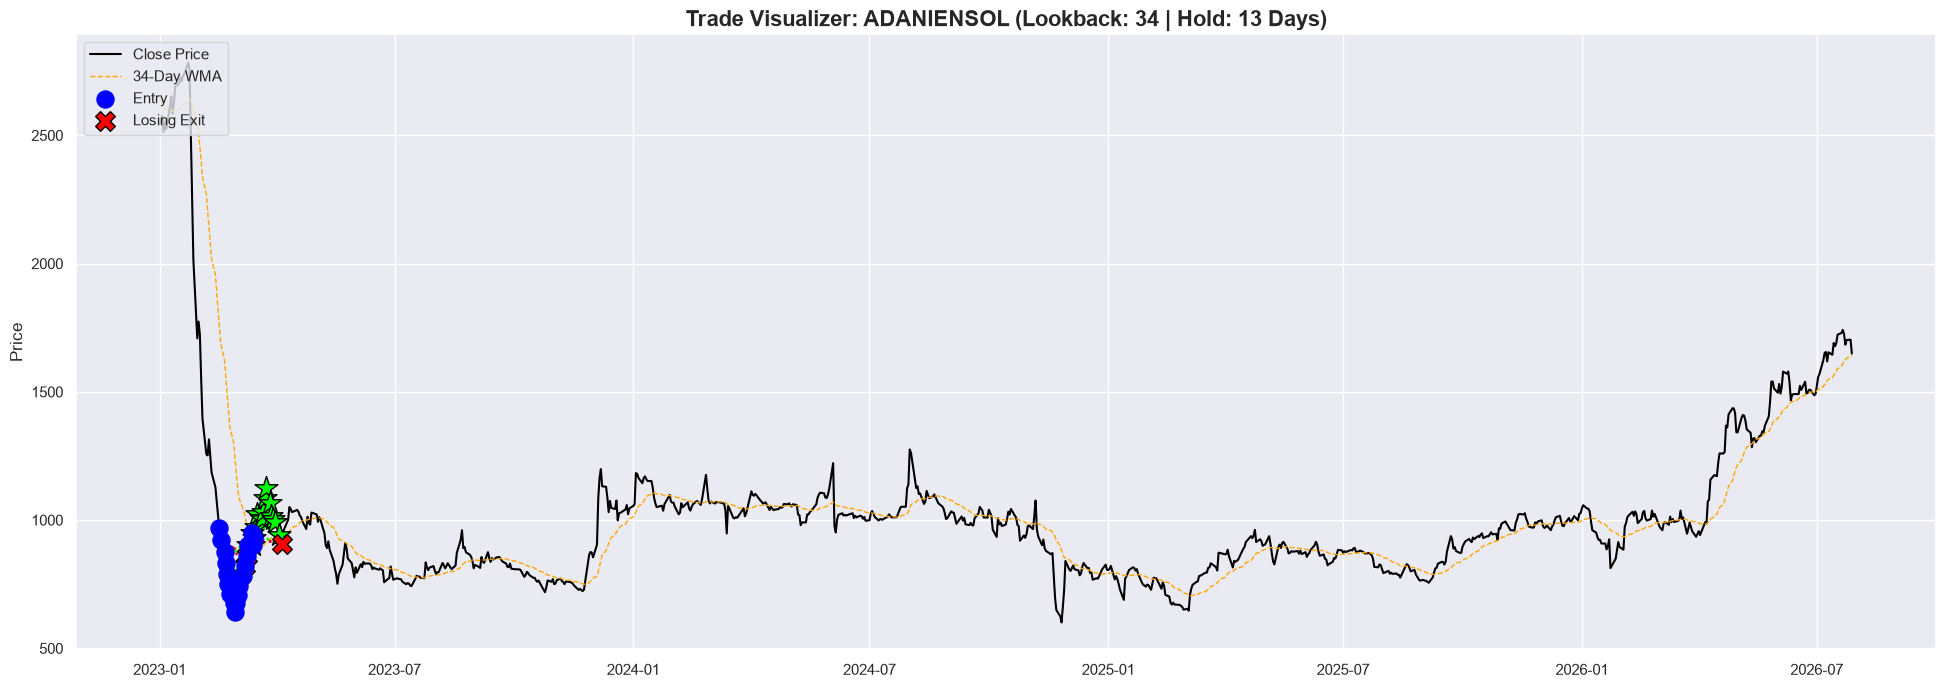

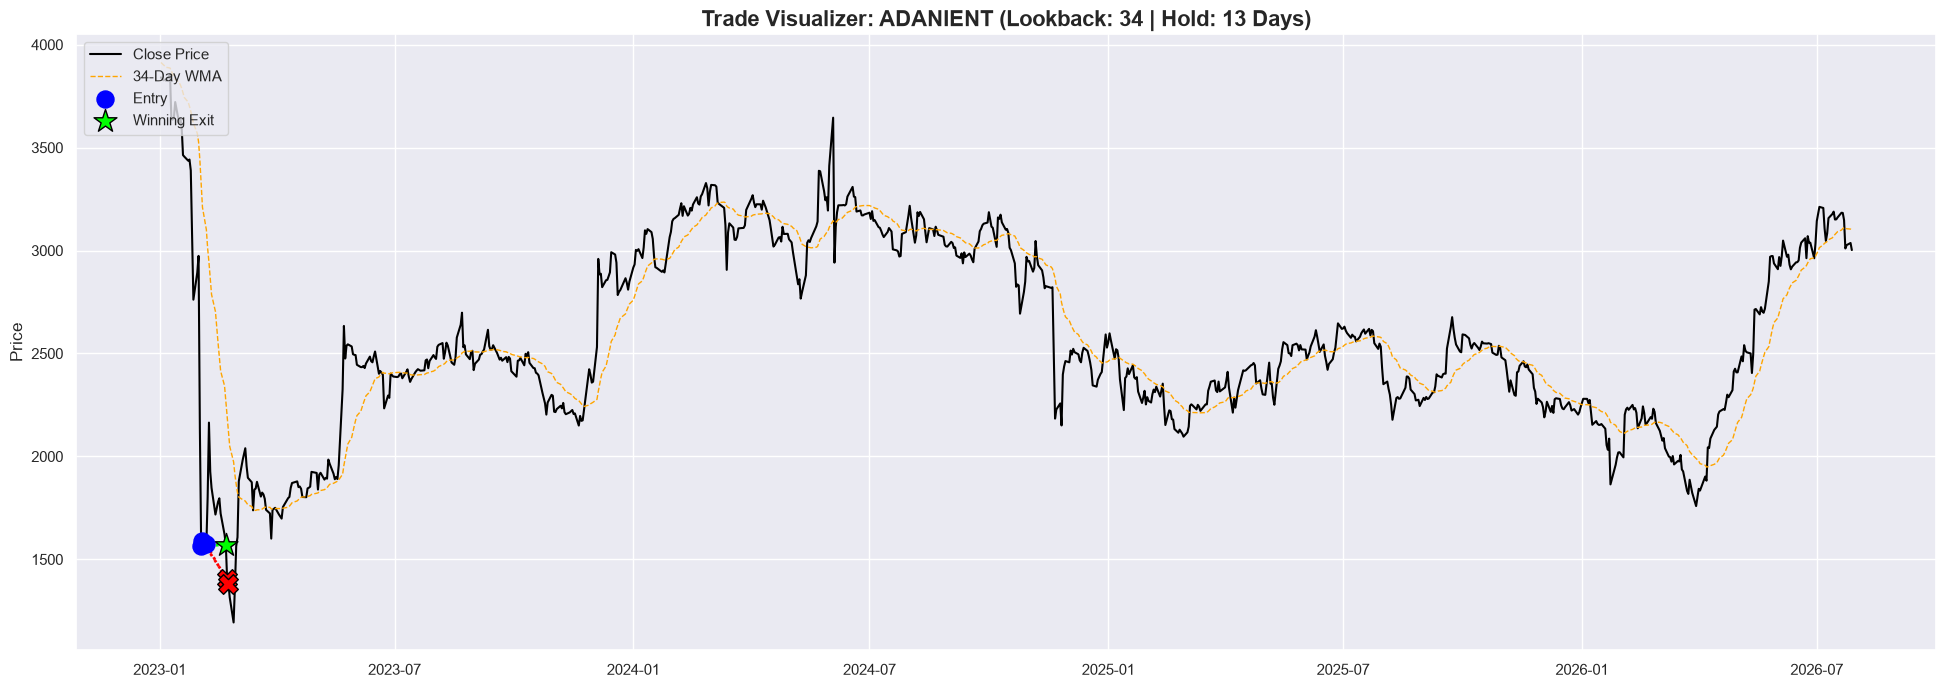

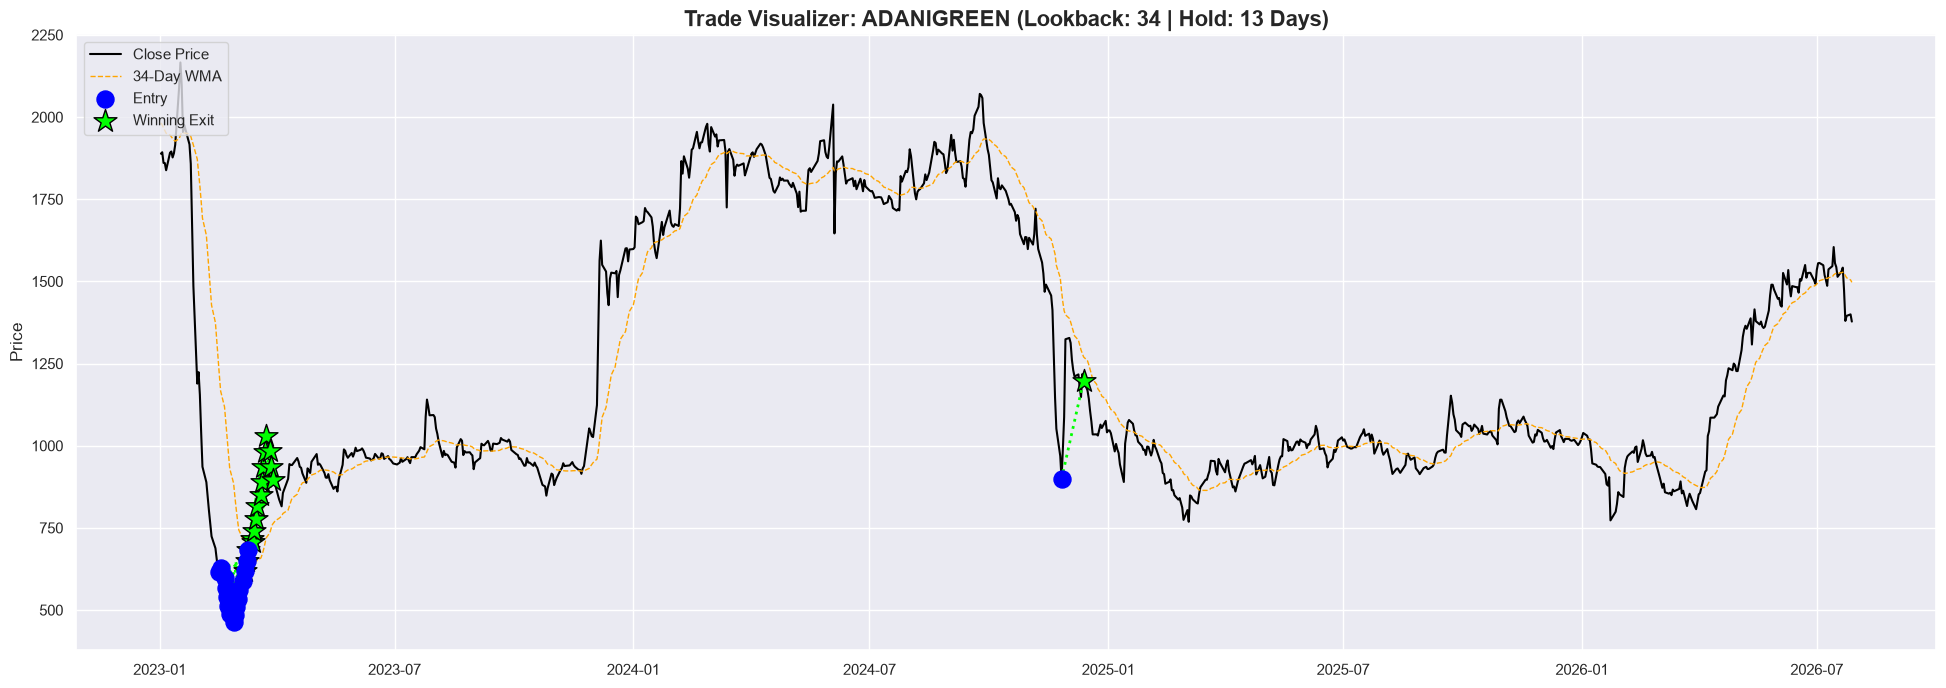

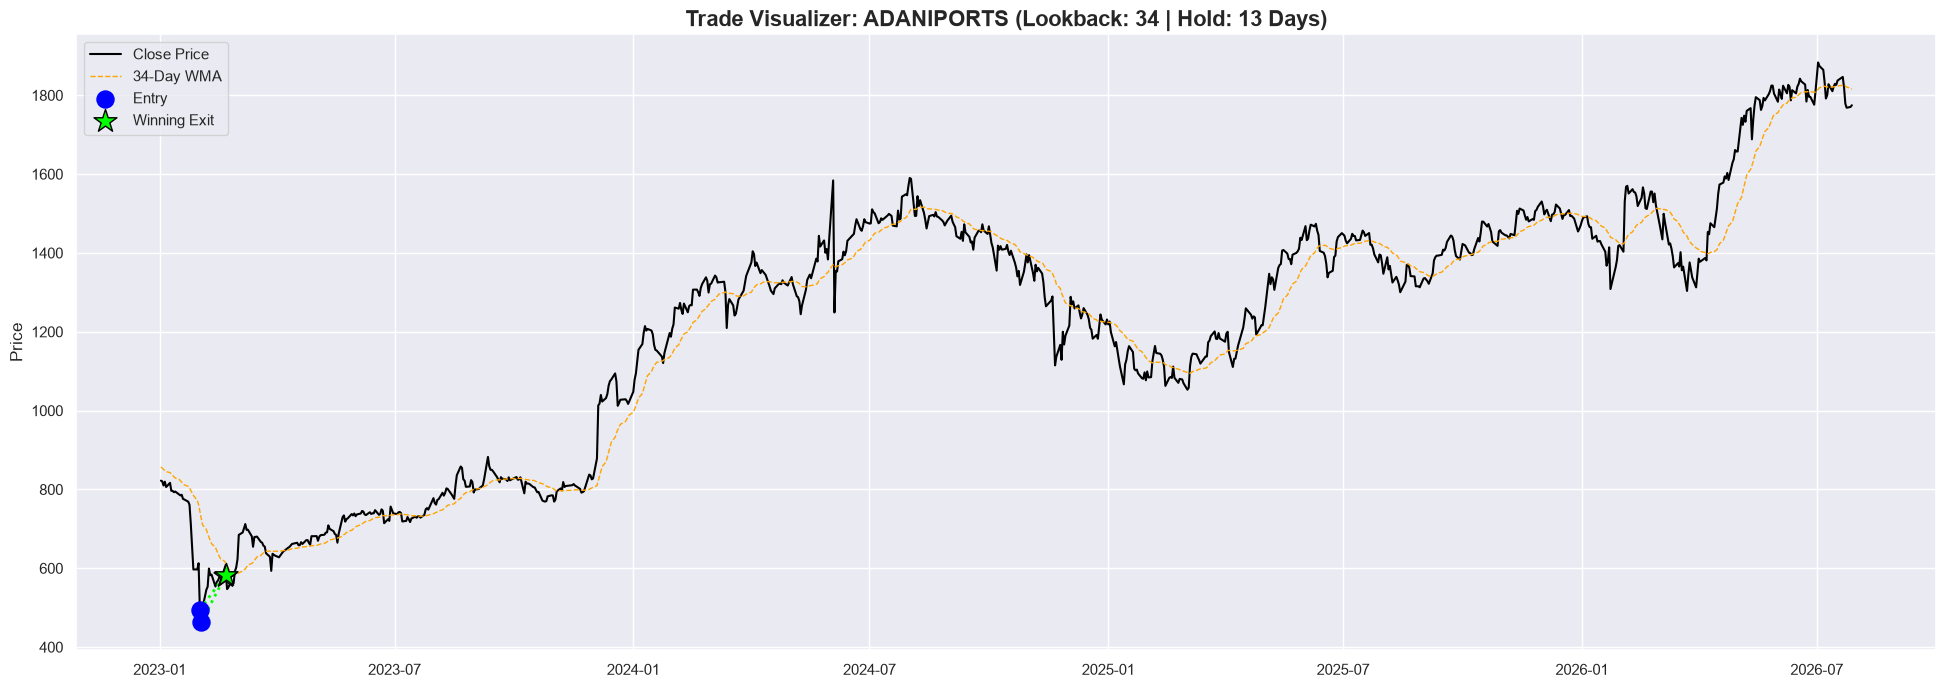

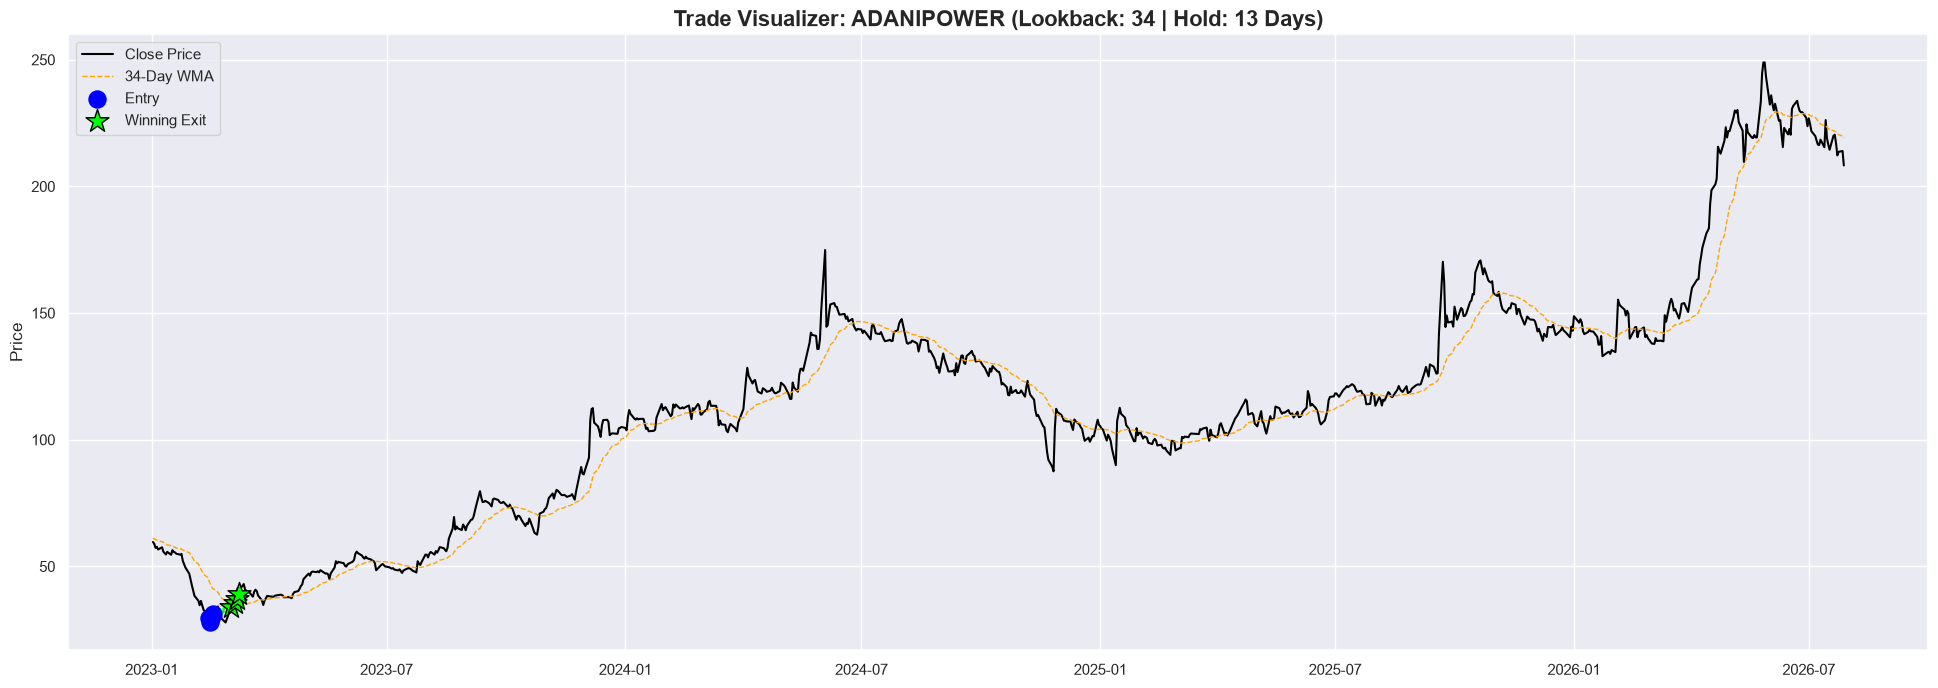

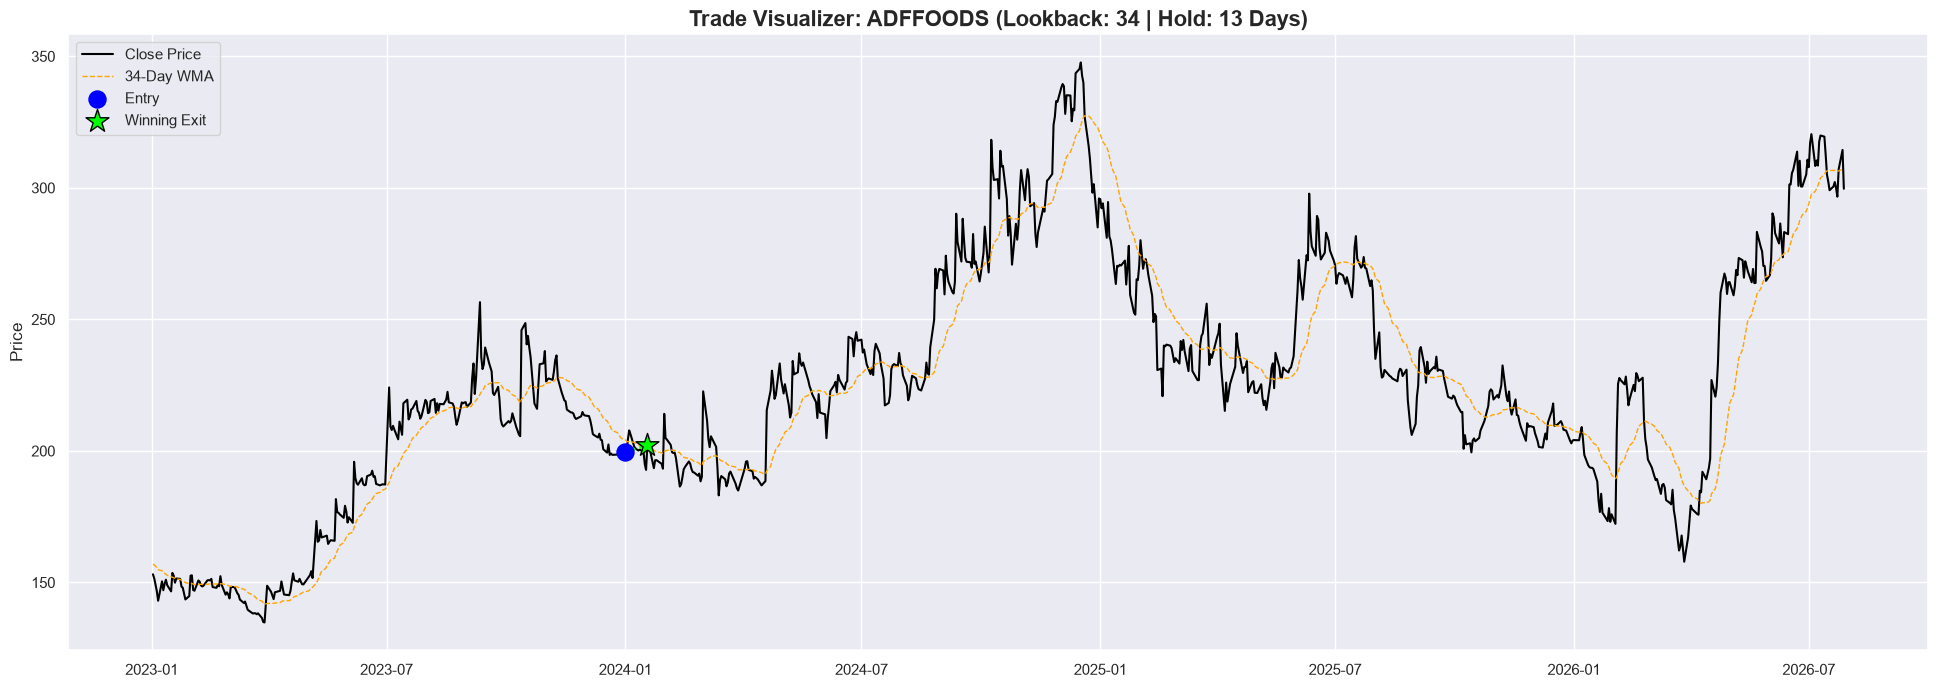

In [5]:
# 5. Row-by-Row Plotting
# We will iterate through every stock that had a trade and plot its entire 2023+ timeline

symbols_with_trades = trades['Symbol'].unique()

for sym in symbols_with_trades:
    stock_df = test_data[test_data['Symbol'] == sym].reset_index(drop=True)
    stock_trades = trades[trades['Symbol'] == sym]
    
    fig, ax = plt.subplots(figsize=(24, 8))
    
    # 1. Base Line Chart
    ax.plot(stock_df['Date'], stock_df['Close'], color='black', linewidth=1.5, label='Close Price')
    
    # 2. Moving Average
    ax.plot(stock_df['Date'], stock_df['WMA'], color='orange', linewidth=1, linestyle='--', label='34-Day WMA')
    
    # 3. Plot Each Trade
    for i, trade_row in stock_trades.iterrows():
        entry_date = trade_row['Date']
        entry_price = trade_row['Close']
        
        # Find the exit row based on holding period
        # We use the original dataframe index + HOLD_DAYS that we calculated
        try:
            # Re-locate the exit date using the shift we did earlier
            # A simpler way is to just find the row HOLD_DAYS rows ahead in stock_df
            entry_idx = stock_df[stock_df['Date'] == entry_date].index[0]
            exit_idx = entry_idx + HOLD_DAYS
            if exit_idx >= len(stock_df): continue # Skip if off edge of graph
            
            exit_date = stock_df.loc[exit_idx, 'Date']
            exit_price = stock_df.loc[exit_idx, 'Close']
            
            is_win = trade_row['Fwd_Ret'] > 0
            
            # Draw Entry
            ax.scatter(entry_date, entry_price, color='blue', s=150, zorder=5, marker='o', label='Entry' if i == stock_trades.index[0] else "")
            
            # Draw Exit
            if is_win:
                ax.scatter(exit_date, exit_price, color='lime', s=300, zorder=5, marker='*', edgecolor='black', label='Winning Exit' if i == stock_trades.index[0] else "")
            else:
                ax.scatter(exit_date, exit_price, color='red', s=200, zorder=5, marker='X', edgecolor='black', label='Losing Exit' if i == stock_trades.index[0] else "")
                
            # Connect them
            line_color = 'lime' if is_win else 'red'
            ax.plot([entry_date, exit_date], [entry_price, exit_price], color=line_color, linestyle=':', linewidth=2, zorder=4)
            
        except IndexError:
            pass # Edge case if date mapping fails
            
    ax.set_title(f"Trade Visualizer: {sym} (Lookback: 34 | Hold: 13 Days)", fontsize=16, fontweight='bold')
    ax.set_ylabel("Price")
    
    # Prevent duplicate labels in legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left')
    
    plt.show()
